In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightkurve as lk

from Work.LightCurve import KIC_dict

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [25]:
import lightkurve as lk
import numpy as np

def download_lcs(kic, n=4894):
    """
    Download a Kepler light curve for a given KIC, preprocess it,
    and split the flux into equal chunks of length n.

    Parameters
    ----------
    kic : int or str
        Kepler ID.
    n : int
        Chunk length.

    Returns
    -------
    chunks : list of np.ndarray
        List of flux chunks, each of length n.
    """

    search_result = lk.search_lightcurve(f"KIC {kic}", author="Kepler")

    lcc = search_result[-5:-1].download_all()

    lc = lcc.stitch().remove_nans().remove_outliers(sigma=5).normalize()
    lc_flat, _ = lc.flatten(window_length=301, return_trend=True)

    flux = np.array(lc_flat.flux, dtype=np.float32)

    chunks = [flux[i:i+n] for i in range(0, len(flux), n) if len(flux[i:i+n]) == n]

    return chunks


<h3>Kepler Exoplanets</h3>

In [26]:
KIC_df = pd.read_csv("Kepler_Data/Kepler_Confirmed_ExoPlanets.csv", skiprows=11)

KIC_df.drop_duplicates(subset="kepid", keep="last").dropna()

,kepid,koi_disposition,koi_score
1,10797460,CONFIRMED,0.969
2,10854555,CONFIRMED,1.000
5,10872983,CONFIRMED,0.992
7,11446443,CONFIRMED,0.811
8,10666592,CONFIRMED,1.000
...,...,...,...
2740,10843431,CONFIRMED,0.994
2741,7350067,CONFIRMED,1.000
2743,8311864,CONFIRMED,0.771
2744,7935997,CONFIRMED,0.000


In [6]:
sum(KIC_df["koi_score"] < 0.900)

206

In [17]:


#{KIC_df["kepid"][100]}

search_result = lk.search_lightcurve(f'KIC {10872983}', author='Kepler')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,1800,kplr010872983,0.0
1,Kepler Quarter 03,2009,Kepler,1800,kplr010872983,0.0
2,Kepler Quarter 04,2010,Kepler,1800,kplr010872983,0.0
3,Kepler Quarter 05,2010,Kepler,1800,kplr010872983,0.0
4,Kepler Quarter 06,2010,Kepler,1800,kplr010872983,0.0
5,Kepler Quarter 10,2011,Kepler,60,kplr010872983,0.0
6,Kepler Quarter 10,2011,Kepler,60,kplr010872983,0.0
7,Kepler Quarter 10,2011,Kepler,60,kplr010872983,0.0
8,Kepler Quarter 09,2011,Kepler,60,kplr010872983,0.0


In [8]:
lcc = search_result[19:21].download_all()

lc = (lcc.stitch().remove_nans().remove_outliers(sigma=5).normalize())

In [9]:
lc_flat, trend = lc.flatten(window_length=301, return_trend=True)

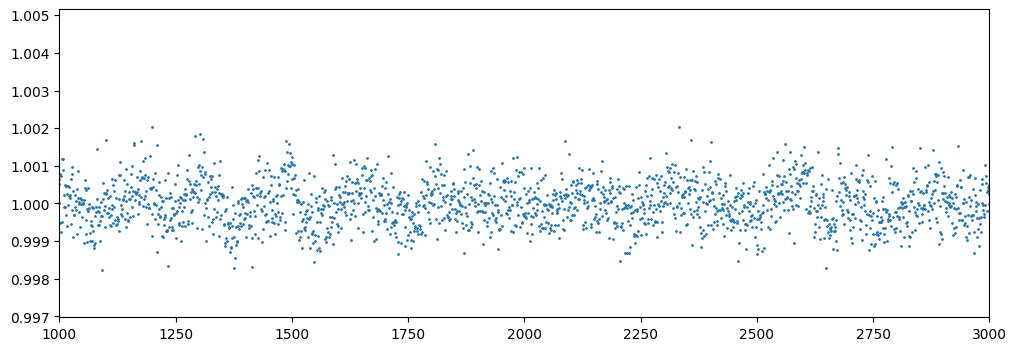

In [10]:
xmin = 1000
xmax = 3000

plt.figure(figsize=[12,4])
plt.xlim(xmin, xmax)
plt.scatter(np.arange(0, len(lc_flat.flux)), lc_flat.flux, s=1)

In [27]:
len(KIC_df)

split = np.arange(0, 2749, 200)
print(split)

[   0  200  400  600  800 1000 1200 1400 1600 1800 2000 2200 2400 2600]


In [28]:
import pandas as pd

for j in range(len(split) - 1):
    kepid_list = []
    exo_list = []

    print(f"Started Split {j}: KIC #{split[j]} to KIC #{split[j+1]}")

    for i, kepid in enumerate(KIC_df.iloc[split[j]:split[j+1]]["kepid"]):
        kic_lcs = download_lcs(kepid, n=4894)   # returns a list of equal-length chunks

        # Add one row per chunk
        for chunk in kic_lcs:
            kepid_list.append(kepid)
            exo_list.append(chunk)

        print(f"\tCompleted section {i}")

    print(f"Completed {j}")

    final_exo_df = pd.DataFrame({
        "kepid": kepid_list,
        "flux": [arr.tolist() for arr in exo_list]
    })

    final_exo_df.to_csv(
        f"Kepler_Data/kepler_flux_{split[j]}_{split[j+1]}.csv",
        index=False,
    )

Started Split 0: KIC #0 to KIC #200
	Completed section 0
	Completed section 1
	Completed section 2
	Completed section 3
	Completed section 4
	Completed section 5
	Completed section 6
	Completed section 7
	Completed section 8
	Completed section 9
	Completed section 10
	Completed section 11
	Completed section 12
	Completed section 13
	Completed section 14
	Completed section 15
	Completed section 16
	Completed section 17
	Completed section 18
	Completed section 19
	Completed section 20
	Completed section 21
	Completed section 22
	Completed section 23
	Completed section 24
	Completed section 25
	Completed section 26
	Completed section 27
	Completed section 28
	Completed section 29
	Completed section 30
	Completed section 31
	Completed section 32
	Completed section 33
	Completed section 34
	Completed section 35
	Completed section 36
	Completed section 37
	Completed section 38
	Completed section 39
	Completed section 40
	Completed section 41
	Completed section 42
	Completed section 43
	Compl

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/search.py:491: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


AttributeError: 'NoneType' object has no attribute 'stitch'

In [25]:
final_exo_df = pd.DataFrame({
    "kepid": kepid_list,
    "flux": [arr.tolist() for arr in exo_list]
})

final_exo_df.to_csv("kepler_flux.csv", index=False)

<h3>Kepler Eclipsing Binaries</h3>

In [13]:
url = "https://archive.stsci.edu/kepler/eclipsing_binaries.html"
eb_df = pd.read_html(url)[0]

# optional: clean column names
eb_df.columns = [str(c).strip() for c in eb_df.columns]

eb_df.to_csv("Kepler_Data/Kepler_Confirmed_EB.csv", index=False)

In [14]:
KEB_df = pd.read_csv("Kepler_Data/Kepler_Confirmed_EB.csv")

In [21]:
KEB_df

,Kepler ID,KOI,Morph,Mult,BJD0,BJD0 Err,Period,Period Err,Kepmag,Teff,RA,Dec
0,1026032,NaN,0.15,1,54966.773813,0.030112,8.460438,2.30e-5,14.813,5715,291.04410,36.72930
1,1026957,958,0.01,1,54956.017106,0.011314,21.761306,8.81e-5,12.559,4845,291.25450,36.74360
2,1161345,984,0.24,1,55005.028983,0.023798,4.287456,8.60e-6,11.631,5836,291.04880,36.83990
3,1432214,998,0.00,1,55047.039254,0.037980,161.788300,1.58e-3,15.661,5814,291.38270,37.07300
4,1433410,NaN,0.74,1,54999.951811,0.014174,0.283275,3.10e-6,14.119,6003,291.63770,37.08230
...,...,...,...,...,...,...,...,...,...,...,...,...
2877,12785282,NaN,0.64,1,54953.956353,0.024042,0.788750,7.00e-7,13.518,6924,290.47120,52.02850
2878,Skip to Main Content MAST STScI Tools exo....,Skip to Main Content MAST STScI Tools exo....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2879,Kepler Data Search Kepler Abstract Search FA...,Kepler Eclipsing Binaries (Revision 3) (downl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2880,Top of Page Copyright Email Questions or Sug...,Top of Page Copyright Email Questions or Sug...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
search_result = lk.search_lightcurve(f'KIC {1026032}', author='Kepler')
search_result

In [ ]:
lcc = search_result[10:13].download_all()

lc = (lcc.stitch().remove_nans().remove_outliers(sigma=5).normalize())

In [ ]:
lc_flat, trend = lc.flatten(window_length=301, return_trend=True)

In [ ]:
xmin = 1000
xmax = 3000

plt.figure(figsize=[12,4])
#plt.xlim(xmin, xmax)
plt.scatter(np.arange(0, len(lc_flat.flux)), lc_flat.flux, s=1)

<h4>Saving flux data</h4>

In [19]:
print(len(KEB_df))

eb_split = np.arange(0, 2882, 200)
print(eb_split)

2882
[   0  200  400  600  800 1000 1200 1400 1600 1800 2000 2200 2400 2600
 2800]


In [23]:
for j in range(0, len(eb_split) - 1):

    kepid_list = []
    eb_list = []

    print(f"Started Split {j}: KIC #{eb_split[j]} to KIC #{eb_split[j+1]}")
    for i, Kepler_df in enumerate(KEB_df.iloc[split[j]:split[j+1]]["Kepler ID"]):
        kic_lcs = download_lcs(Kepler_df)
        kepid_list.append(Kepler_df)
        eb_list.append(kic_lcs)
        print(f"\t Completed section {i}")
    print(f"Completed {j}")

    final_exo_df = pd.DataFrame({
    "kepid": kepid_list,
    "flux": [arr.tolist() for arr in exo_list]
    })

    final_exo_df.to_csv(f"Kepler_Data/keplerEB_flux_{eb_split[j]}_{eb_split[j+1]}.csv", index=False)

Started Split 0: KIC #0 to KIC #200
	 Completed section 0
	 Completed section 1
	 Completed section 2
	 Completed section 3
	 Completed section 4
	 Completed section 5
	 Completed section 6
	 Completed section 7
	 Completed section 8
	 Completed section 9
	 Completed section 10
	 Completed section 11
	 Completed section 12
	 Completed section 13
	 Completed section 14
	 Completed section 15
	 Completed section 16
	 Completed section 17
	 Completed section 18
	 Completed section 19
	 Completed section 20
	 Completed section 21
	 Completed section 22
	 Completed section 23
	 Completed section 24
	 Completed section 25
	 Completed section 26
	 Completed section 27
	 Completed section 28
	 Completed section 29
	 Completed section 30
	 Completed section 31
	 Completed section 32
	 Completed section 33
	 Completed section 34
	 Completed section 35
	 Completed section 36
	 Completed section 37
	 Completed section 38
	 Completed section 39
	 Completed section 40
	 Completed section 41
	 Comple

ValueError: All arrays must be of the same length

<h3>Kepler Normal Stars</h3>

In [ ]:
K_Norm_df = pd.read_csv("Kepler_Data/Kepler_Possible_Normal.csv")


CHANGE UP

In [2]:
import numpy as np

In [3]:
data = np.load("/Users/aaryanthusoo/Desktop/UCL/CNN_Exoplanets/data/multi_model/test.npz")

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np

PROJECT_ROOT = Path.cwd().parents[0]  # change if needed
EB_DIR = PROJECT_ROOT / "data" / "processed" / "eb_data"

eb_files = sorted(EB_DIR.glob("kepler_eb_flux_*.csv"))

eb_df = pd.concat(
    [pd.read_csv(file) for file in eb_files],
    ignore_index=True
)

eb_df.head()

,kepid,flux,depth,deep
0,1026032,"[1.0, 0.995570719242096, 0.9994664192199707, 0...",0.995549,False
1,1026032,"[1.0010212659835815, 1.0001720190048218, 1.000...",0.995549,False
2,1026032,"[0.9997212886810303, 0.9995341300964355, 0.999...",0.995549,False
3,1026957,"[0.9993830323219299, 0.9998487830162048, 0.999...",0.981862,True
4,1026957,"[0.9992536306381226, 0.9991442561149597, 0.999...",0.981862,True


In [5]:
depths = eb_df["depth"].dropna()

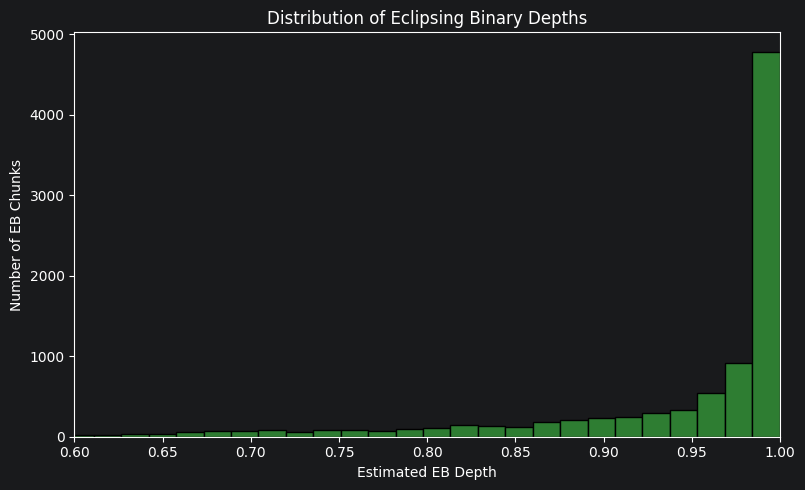

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(depths, bins=80, edgecolor="black", color="#2e7d32")
plt.xlabel("Estimated EB Depth")
plt.ylabel("Number of EB Chunks")
plt.title("Distribution of Eclipsing Binary Depths")
plt.tight_layout()
plt.xlim(0.6, 1)
plt.show()